In [7]:
import pandas as pd 
import nltk
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from nltk.corpus import stopwords

In [56]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from nltk.stem import WordNetLemmatizer
import re

In [9]:
df = pd.read_csv(r'C:\Users\mitad\OneDrive\Documents\coding_maxxing\sentiment_analysing_project\artifacts\youtube_comments_cleaned.csv')
df.head()

,CommentID,VideoID,VideoTitle,AuthorName,AuthorChannelID,CommentText,Sentiment,Likes,Replies,PublishedAt,CountryCode,CategoryID
0,UgyRjrEdJIPrf68uND14AaABAg,mcY4M9gjtsI,They killed my friend.#tales #movie #shorts,@OneWhoWandered,UC_-UEXaBL1dqqUPGkDll49A,Anyone know what movie this is?,Neutral,0,2,15-01-2025 00:54,NZ,1
1,UgxXxEIySAwnMNw8D7N4AaABAg,2vuXcw9SZbA,Man Utd conceding first penalty at home in yea...,@chiefvon3068,UCZ1LcZESjYqzaQRhjdZJFwg,The fact they're holding each other back while...,Positive,0,0,13-01-2025 23:51,AU,17
2,UgxB0jh2Ur41mcXr5IB4AaABAg,papg2tsoFzg,Welcome to Javascript Course,@Abdulla-ip8qr,UCWBK35w5Swy1iF5xIbEyw3A,waiting next video will be?,Neutral,1,0,06-07-2020 13:18,IN,27
3,UgwMOh95MfK0GuXLLrF4AaABAg,31KTdfRH6nY,Building web applications in Java with Spring ...,@finnianthehuman,UCwQ2Z03nOcMxWozBb_Cv66w,Thanks for the great video.\n\nI don't underst...,Neutral,0,1,18-09-2024 12:04,US,27
4,UgxJuUe5ysG8OSbABAl4AaABAg,#NAME?,After a new engine her car dies on her way hom...,@ryoutubeplaylistb6137,UCTTcJ0tsAKQokmHB2qVb1qQ,Good person helping good people.\nThis is how ...,Positive,3,1,10-01-2025 19:39,US,2


In [10]:
df.shape

(1032225, 12)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1032225 entries, 0 to 1032224
Data columns (total 12 columns):
 #   Column           Non-Null Count    Dtype
---  ------           --------------    -----
 0   CommentID        1032225 non-null  str  
 1   VideoID          1032225 non-null  str  
 2   VideoTitle       1032225 non-null  str  
 3   AuthorName       1031594 non-null  str  
 4   AuthorChannelID  1032225 non-null  str  
 5   CommentText      1032225 non-null  str  
 6   Sentiment        1032225 non-null  str  
 7   Likes            1032225 non-null  int64
 8   Replies          1032225 non-null  int64
 9   PublishedAt      1032225 non-null  str  
 10  CountryCode      1032225 non-null  str  
 11  CategoryID       1032225 non-null  int64
dtypes: int64(3), str(9)
memory usage: 94.5 MB


In [12]:
df.describe()

,Likes,Replies,CategoryID
count,1.032225e+06,1.032225e+06,1.032225e+06
mean,1.016608e+02,2.023081e+00,2.318282e+01
std,1.538978e+03,1.414470e+01,6.271585e+00
min,0.000000e+00,0.000000e+00,1.000000e+00
25%,0.000000e+00,0.000000e+00,2.400000e+01
50%,0.000000e+00,0.000000e+00,2.500000e+01
75%,2.000000e+00,0.000000e+00,2.700000e+01
max,2.758490e+05,7.510000e+02,2.800000e+01


In [13]:
df.isnull().sum()

CommentID            0
VideoID              0
VideoTitle           0
AuthorName         631
AuthorChannelID      0
CommentText          0
Sentiment            0
Likes                0
Replies              0
PublishedAt          0
CountryCode          0
CategoryID           0
dtype: int64

In [14]:
df['CommentText'].value_counts()

CommentText
❤                                                                                                                                   1169
Thanks                                                                                                                               507
Thanks!                                                                                                                              502
❤❤❤                                                                                                                                  455
😂😂😂                                                                                                                                  423
                                                                                                                                    ... 
me here just to read peoples comments about their hate for this ban and laugh at them.                                                 1
Any recommendations for how t

In [15]:
df[df['CommentText'].isna()]

,CommentID,VideoID,VideoTitle,AuthorName,AuthorChannelID,CommentText,Sentiment,Likes,Replies,PublishedAt,CountryCode,CategoryID


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
#covert the 'CommentText' column to Lowercase
df['CommentText'] = df['CommentText'].str.lower()
df.head()

,CommentID,VideoID,VideoTitle,AuthorName,AuthorChannelID,CommentText,Sentiment,Likes,Replies,PublishedAt,CountryCode,CategoryID
0,UgyRjrEdJIPrf68uND14AaABAg,mcY4M9gjtsI,They killed my friend.#tales #movie #shorts,@OneWhoWandered,UC_-UEXaBL1dqqUPGkDll49A,anyone know what movie this is?,Neutral,0,2,15-01-2025 00:54,NZ,1
1,UgxXxEIySAwnMNw8D7N4AaABAg,2vuXcw9SZbA,Man Utd conceding first penalty at home in yea...,@chiefvon3068,UCZ1LcZESjYqzaQRhjdZJFwg,the fact they're holding each other back while...,Positive,0,0,13-01-2025 23:51,AU,17
2,UgxB0jh2Ur41mcXr5IB4AaABAg,papg2tsoFzg,Welcome to Javascript Course,@Abdulla-ip8qr,UCWBK35w5Swy1iF5xIbEyw3A,waiting next video will be?,Neutral,1,0,06-07-2020 13:18,IN,27
3,UgwMOh95MfK0GuXLLrF4AaABAg,31KTdfRH6nY,Building web applications in Java with Spring ...,@finnianthehuman,UCwQ2Z03nOcMxWozBb_Cv66w,thanks for the great video.\n\ni don't underst...,Neutral,0,1,18-09-2024 12:04,US,27
4,UgxJuUe5ysG8OSbABAl4AaABAg,#NAME?,After a new engine her car dies on her way hom...,@ryoutubeplaylistb6137,UCTTcJ0tsAKQokmHB2qVb1qQ,good person helping good people.\nthis is how ...,Positive,3,1,10-01-2025 19:39,US,2


In [18]:
#remove any leading or trailing whitespace letters in the 'CommentText' column
df['CommentText'] = df['CommentText'].str.strip()
#verify the transformation by checking the presence of any whitespace letters in the 'CommentText' column
df['CommentText'].apply(lambda x: x.endswith(' ') or x.startswith(' ')).sum()

np.int64(0)

In [19]:
#identify comments that contain url letters in the 'CommentText' column
url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
comments_with_urls = df[df['CommentText'].str.contains(url_pattern, na=False)]

In [20]:
#identify comments that contain new line characters in the 'CommentText' column
comments_with_newlines = df[df['CommentText'].str.contains('\n', na=False)]

EDA

C:\Users\mitad\AppData\Local\Temp\ipykernel_18188\3558108158.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='Sentiment',palette='Set2')


<function matplotlib.pyplot.show(close=None, block=None)>

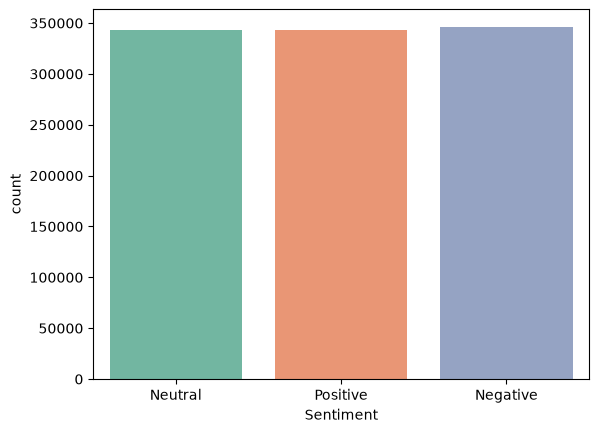

In [21]:
sns.countplot(data=df,x='Sentiment',palette='Set2')
plt.show

In [22]:
df['Sentiment'].value_counts(normalize=True).mul(100).round(2)

Sentiment
Negative    33.53
Positive    33.26
Neutral     33.21
Name: proportion, dtype: float64

In [23]:
df['Word_Count']=df['CommentText'].apply(lambda x: len(str(x).split()))
df.head()

,CommentID,VideoID,VideoTitle,AuthorName,AuthorChannelID,CommentText,Sentiment,Likes,Replies,PublishedAt,CountryCode,CategoryID,Word_Count
0,UgyRjrEdJIPrf68uND14AaABAg,mcY4M9gjtsI,They killed my friend.#tales #movie #shorts,@OneWhoWandered,UC_-UEXaBL1dqqUPGkDll49A,anyone know what movie this is?,Neutral,0,2,15-01-2025 00:54,NZ,1,6
1,UgxXxEIySAwnMNw8D7N4AaABAg,2vuXcw9SZbA,Man Utd conceding first penalty at home in yea...,@chiefvon3068,UCZ1LcZESjYqzaQRhjdZJFwg,the fact they're holding each other back while...,Positive,0,0,13-01-2025 23:51,AU,17,13
2,UgxB0jh2Ur41mcXr5IB4AaABAg,papg2tsoFzg,Welcome to Javascript Course,@Abdulla-ip8qr,UCWBK35w5Swy1iF5xIbEyw3A,waiting next video will be?,Neutral,1,0,06-07-2020 13:18,IN,27,5
3,UgwMOh95MfK0GuXLLrF4AaABAg,31KTdfRH6nY,Building web applications in Java with Spring ...,@finnianthehuman,UCwQ2Z03nOcMxWozBb_Cv66w,thanks for the great video.\n\ni don't underst...,Neutral,0,1,18-09-2024 12:04,US,27,91
4,UgxJuUe5ysG8OSbABAl4AaABAg,#NAME?,After a new engine her car dies on her way hom...,@ryoutubeplaylistb6137,UCTTcJ0tsAKQokmHB2qVb1qQ,good person helping good people.\nthis is how ...,Positive,3,1,10-01-2025 19:39,US,2,19


In [24]:
df['Word_Count'].describe()

count    1.032225e+06
mean     1.920484e+01
std      3.006004e+01
min      0.000000e+00
25%      6.000000e+00
50%      1.200000e+01
75%      2.200000e+01
max      1.796000e+03
Name: Word_Count, dtype: float64

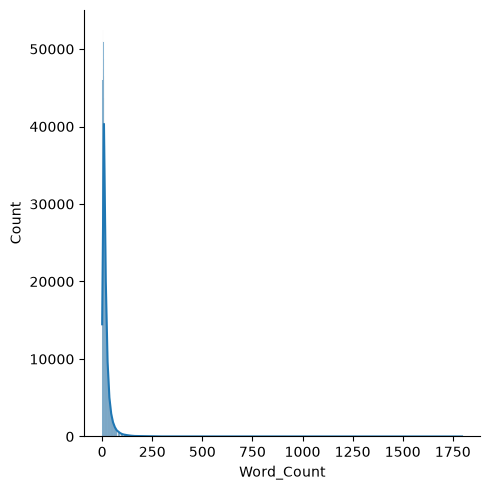

In [25]:
sns.displot(df['Word_Count'], kde=True)
plt.show()

C:\Users\mitad\AppData\Local\Temp\ipykernel_18188\2210187269.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Sentiment']=='Positive']['Word_Count'], label='Positive', shade=True)
C:\Users\mitad\AppData\Local\Temp\ipykernel_18188\2210187269.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Sentiment']=='Negative']['Word_Count'], label='Negative', shade=True)
C:\Users\mitad\AppData\Local\Temp\ipykernel_18188\2210187269.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Sentiment']=='Neutral']['Word_Count'], label='Neutral', shade=True)


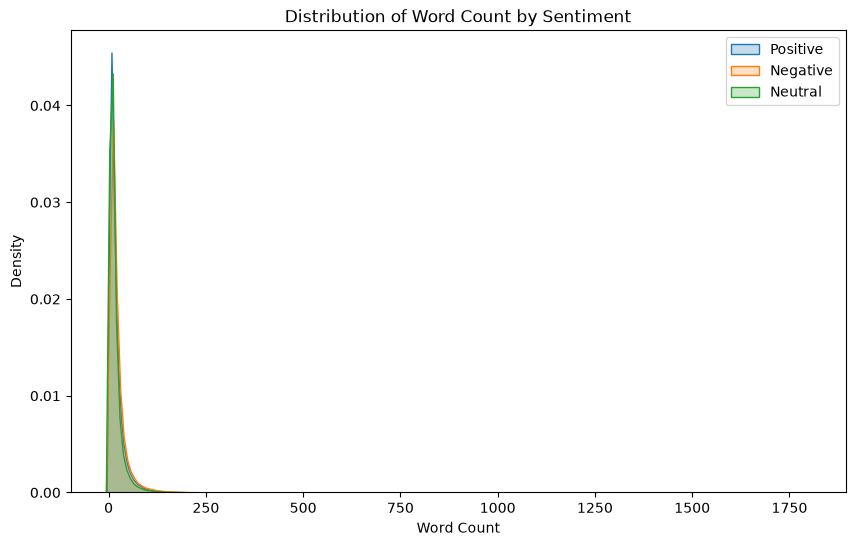

In [26]:
plt.figure(figsize=(10,6))
sns.kdeplot(df[df['Sentiment']=='Positive']['Word_Count'], label='Positive', shade=True)
sns.kdeplot(df[df['Sentiment']=='Negative']['Word_Count'], label='Negative', shade=True)
sns.kdeplot(df[df['Sentiment']=='Neutral']['Word_Count'], label='Neutral', shade=True)
plt.title('Distribution of Word Count by Sentiment')
plt.xlabel('Word Count')
plt.ylabel('Density')
plt.legend()
plt.show()

C:\Users\mitad\AppData\Local\Temp\ipykernel_18188\3396319344.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Sentiment',y='Word_Count',palette='Set2')


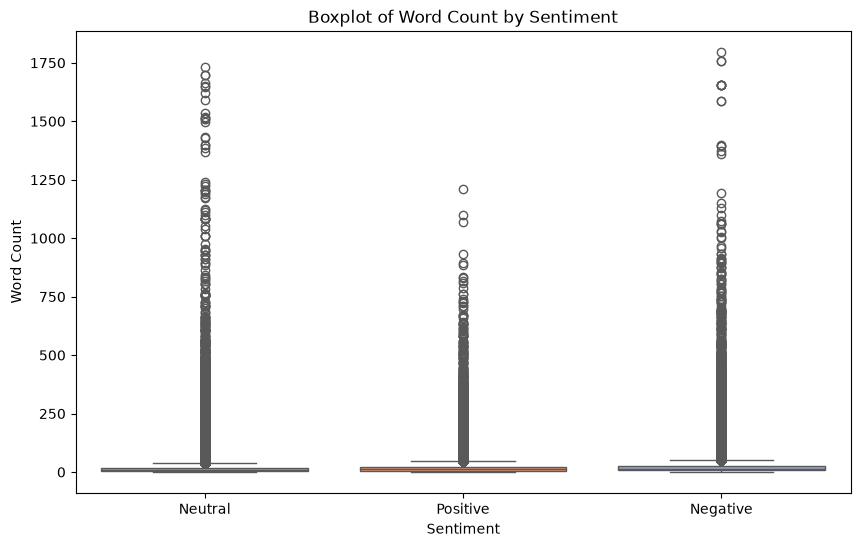

In [27]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='Sentiment',y='Word_Count',palette='Set2')
plt.title('Boxplot of Word Count by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Word Count')
plt.show()


c:\Users\mitad\OneDrive\Documents\coding_maxxing\sentiment_analysing_project\myvenv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


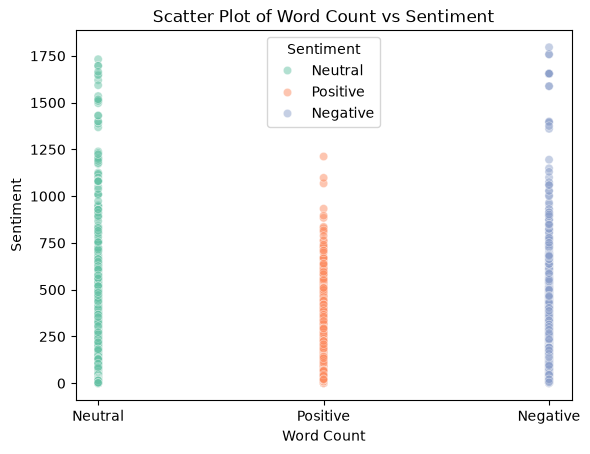

In [28]:
sns.scatterplot(data=df,y='Word_Count',x='Sentiment',hue='Sentiment',palette='Set2',alpha=0.5)
plt.title('Scatter Plot of Word Count vs Sentiment')
plt.xlabel('Word Count')    
plt.ylabel('Sentiment')
plt.show()

C:\Users\mitad\AppData\Local\Temp\ipykernel_18188\1435390415.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='Sentiment',y='Word_Count',palette='Set2')


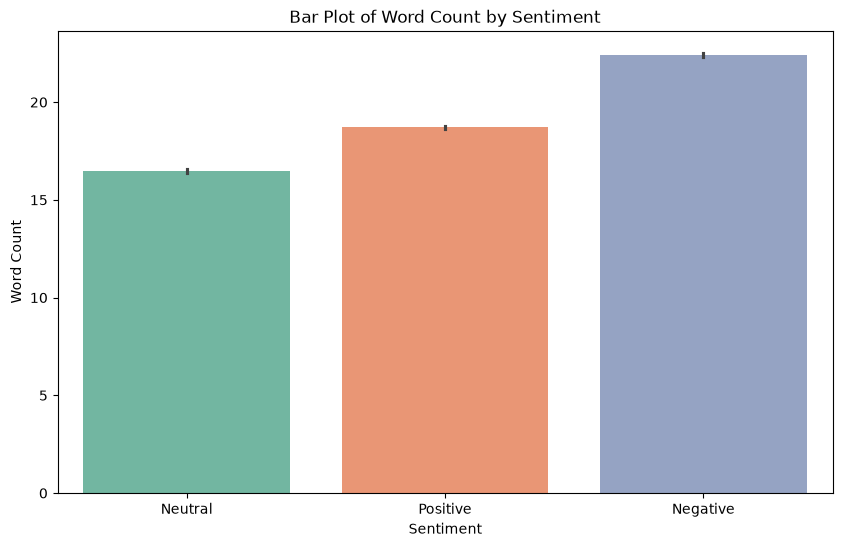

In [29]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,x='Sentiment',y='Word_Count',palette='Set2')
plt.title('Bar Plot of Word Count by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Word Count')
plt.show()

In [30]:
df = df[['CommentText', 'Sentiment', 'Word_Count','Likes','Replies']]
df.head(5)

,CommentText,Sentiment,Word_Count,Likes,Replies
0,anyone know what movie this is?,Neutral,6,0,2
1,the fact they're holding each other back while...,Positive,13,0,0
2,waiting next video will be?,Neutral,5,1,0
3,thanks for the great video.\n\ni don't underst...,Neutral,91,0,1
4,good person helping good people.\nthis is how ...,Positive,19,3,1


In [31]:
le=LabelEncoder()
labeled_sentiment=le.fit_transform(df['Sentiment'])
custom_mapping = {'Negative' : -1, 'Neutral' : 0, 'Positive' : 1}
le=LabelEncoder()
labeled_sentiment = [custom_mapping[label] for label in df['Sentiment']]
df['Sentiment'] = labeled_sentiment

In [32]:
df.head(20)

,CommentText,Sentiment,Word_Count,Likes,Replies
0,anyone know what movie this is?,0,6,0,2
1,the fact they're holding each other back while...,1,13,0,0
2,waiting next video will be?,0,5,1,0
3,thanks for the great video.\n\ni don't underst...,0,91,0,1
4,good person helping good people.\nthis is how ...,1,19,3,1
5,dei løk de seim😂,0,4,0,0
6,number two because it looks the best with it,1,9,0,0
7,thank god we don’t have to listen to his drive...,1,11,0,0
8,very similar thing happened to me! we lived ne...,1,153,0,0
9,im about to cry😢,-1,4,0,0


In [33]:
#Download the stop words from the NLTK library
nltk.download('stopwords')

#Define the stop words from the NLTK library
stop_words = set(stopwords.words('english'))
stop_words.discard('not')  # Remove 'not' from the stop words list

#Create a new column in the dataframe that contains the number of stop words in each comment
df['Stop_Word_Count'] = df['CommentText'].apply(lambda x: len([word for word in str(x).split() if word in stop_words]))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mitad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [34]:
df.head(5)

,CommentText,Sentiment,Word_Count,Likes,Replies,Stop_Word_Count
0,anyone know what movie this is?,0,6,0,2,2
1,the fact they're holding each other back while...,1,13,0,0,7
2,waiting next video will be?,0,5,1,0,1
3,thanks for the great video.\n\ni don't underst...,0,91,0,1,45
4,good person helping good people.\nthis is how ...,1,19,3,1,10


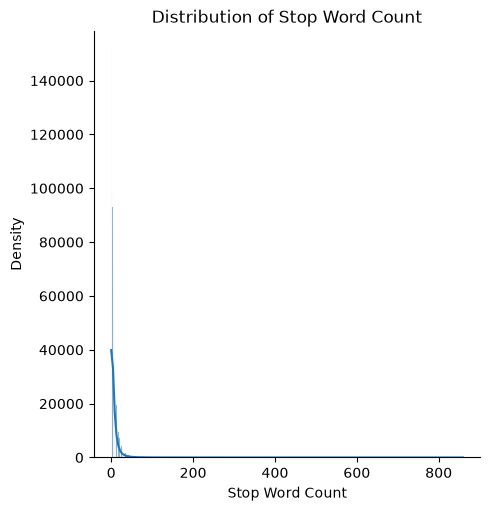

In [35]:
#create a distribution plot of the 'Stop_Word_Count' column
sns.displot(df['Stop_Word_Count'], kde=True)
plt.title('Distribution of Stop Word Count')
plt.xlabel('Stop Word Count')
plt.ylabel('Density')
plt.show()

C:\Users\mitad\AppData\Local\Temp\ipykernel_18188\4146771663.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='Sentiment',y='Stop_Word_Count',palette='Set2',estimator=np.median)


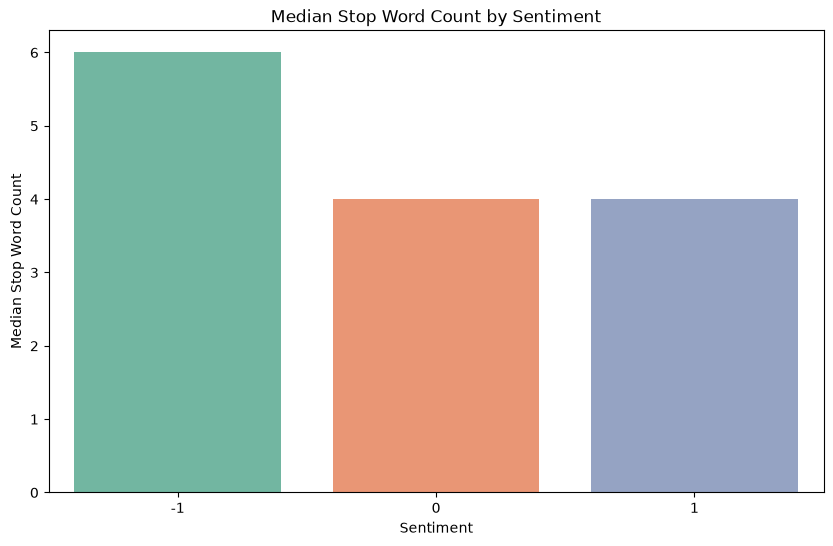

In [36]:
# barplot median of the 'Stop_Word_Count' column
plt.figure(figsize=(10,6))
sns.barplot(data=df,x='Sentiment',y='Stop_Word_Count',palette='Set2',estimator=np.median)
plt.title('Median Stop Word Count by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Median Stop Word Count')
plt.show()

C:\Users\mitad\AppData\Local\Temp\ipykernel_18188\3175666729.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=most_common_stop_words_df, x='Stop_Word', y='Count',palette='viridis')


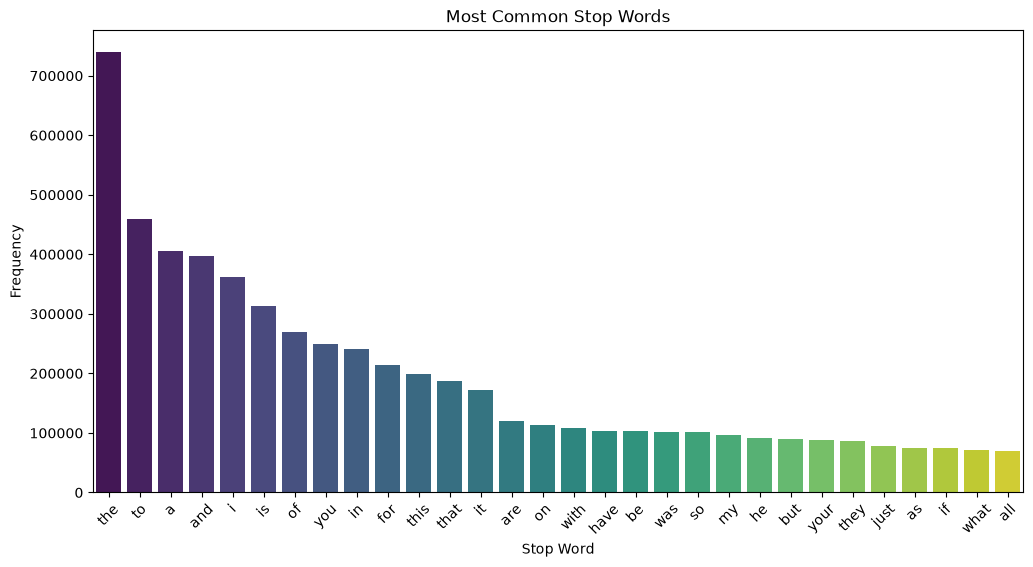

In [37]:
#create a frequency distribution of each stop word in the 'CommentText' column
#Extract all the words from the 'CommentText' column using common stop words
all_stop_words = [word for comment in df['CommentText'] for word in comment.split() if word in stop_words]
most_common_stop_words = Counter(all_stop_words).most_common(30)

#Conver t the most common stop words into a dataframe for visualization
most_common_stop_words_df = pd.DataFrame(most_common_stop_words, columns=['Stop_Word', 'Count'])

#create a bar plot of the most common stop words
plt.figure(figsize=(12,6))
sns.barplot(data=most_common_stop_words_df, x='Stop_Word', y='Count',palette='viridis')
plt.title('Most Common Stop Words')
plt.xlabel('Stop Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

In [38]:
df['num_chars'] = df['CommentText'].apply(lambda x: len(str(x)))
df.head()

,CommentText,Sentiment,Word_Count,Likes,Replies,Stop_Word_Count,num_chars
0,anyone know what movie this is?,0,6,0,2,2,31
1,the fact they're holding each other back while...,1,13,0,0,7,79
2,waiting next video will be?,0,5,1,0,1,27
3,thanks for the great video.\n\ni don't underst...,0,91,0,1,45,488
4,good person helping good people.\nthis is how ...,1,19,3,1,10,94


In [39]:
#combine all the comments into a single string for word cloud generation
all_comments = ' '.join(df['CommentText'].astype(str))

#count the freaquency of each character in all_comments
char_freq = Counter(all_comments)

#convert the character frequency into a dataframe for visualization
char_freq_df = pd.DataFrame(char_freq.items(), columns=['Character', 'Count']).sort_values(by='Count', ascending=False)
char_freq_df.tail(20)

,Character,Count
8366,攔,1
8365,伐,1
8347,僞,1
8346,艸,1
8361,佣,1
8360,浴,1
8359,ڵ,1
8358,ꭲ,1
8357,흘,1
8356,ৈ,1


In [ ]:
#create a column in the dataframe that contains the number of punctuation characters in each comment
df['Punctuation_Count'] = df['CommentText'].apply(lambda x: len([char for char in str(x) if char in ['!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', ':', ';', '<', '=', '>', '?', '@', '[', '\\', ']', '^', '_', '`', '{', '|', '}', '~']]))

In [41]:
df.head()

,CommentText,Sentiment,Word_Count,Likes,Replies,Stop_Word_Count,num_chars,Punctuation_Count
0,anyone know what movie this is?,0,6,0,2,2,31,1
1,the fact they're holding each other back while...,1,13,0,0,7,79,1
2,waiting next video will be?,0,5,1,0,1,27,1
3,thanks for the great video.\n\ni don't underst...,0,91,0,1,45,488,9
4,good person helping good people.\nthis is how ...,1,19,3,1,10,94,2


In [42]:
#create a function that extracts top 25 bigrams from the 'CommentText' column
def get_top_bigrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2),stop_words=list(stop_words))
    bag_of_words = vec.fit_transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n] if n else words_freq

In [43]:
top_25_bigrams = get_top_bigrams(df['CommentText'], n=25)
top_25_bigrams_df = pd.DataFrame(top_25_bigrams, columns=['Bigram', 'Count'])

C:\Users\mitad\AppData\Local\Temp\ipykernel_18188\3802999722.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_bigrams_df, y='Bigram', x='Count',palette='viridis')


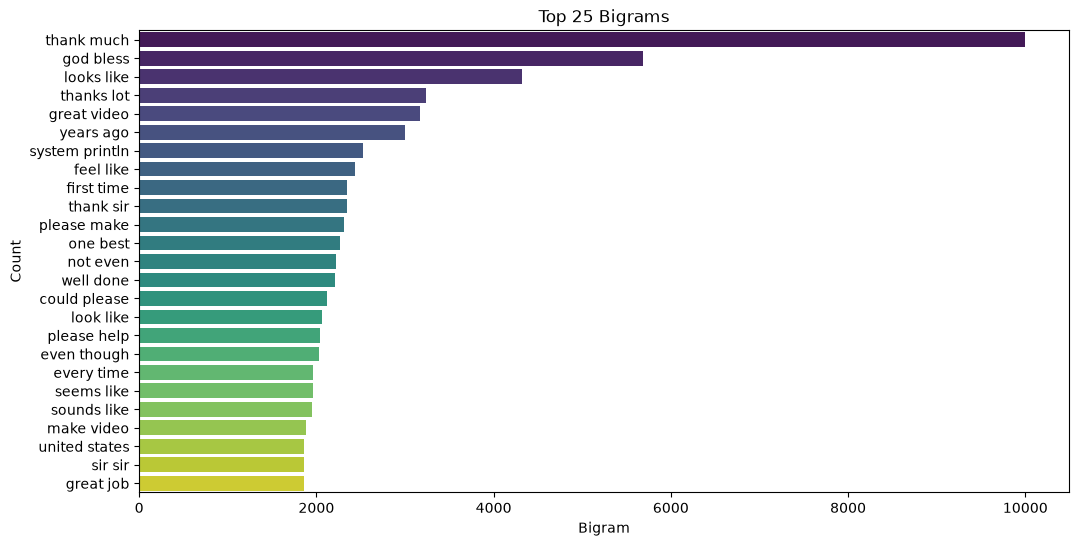

In [45]:
#plot the top 25 bigrams in a bar plot
plt.figure(figsize=(12,6))
sns.barplot(data=top_25_bigrams_df, y='Bigram', x='Count',palette='viridis')
plt.title('Top 25 Bigrams')
plt.xlabel('Bigram')
plt.ylabel('Count')
plt.show()

C:\Users\mitad\AppData\Local\Temp\ipykernel_18188\2032151472.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_trigrams_df, y='Trigram', x='Count',palette='viridis')


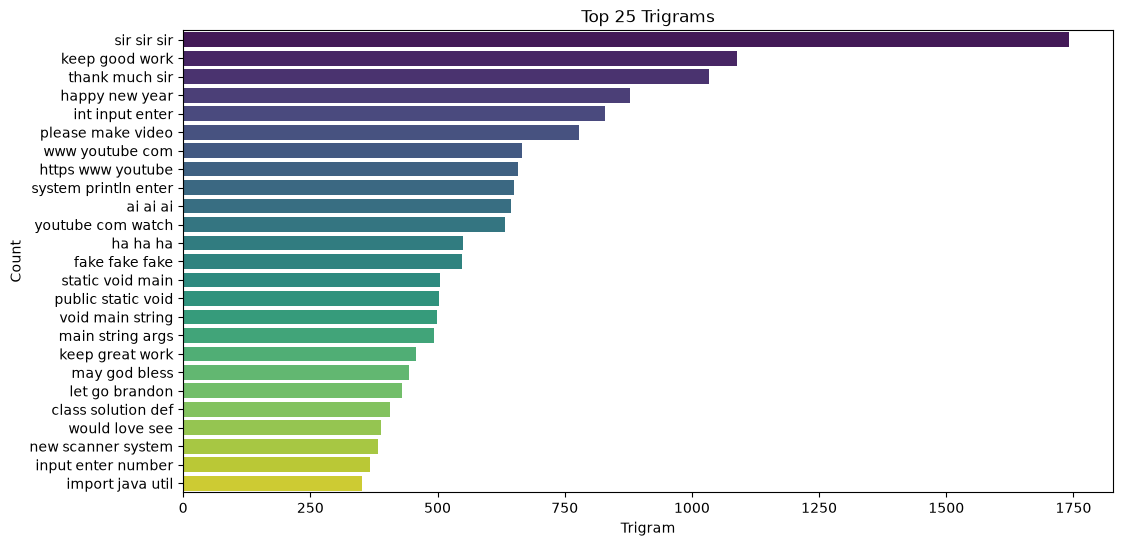

In [46]:
#create a function that extracts top 25 trigrams from the 'CommentText' column
def get_top_trigrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(3, 3),stop_words=list(stop_words))
    bag_of_words = vec.fit_transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n] if n else words_freq

top_25_trigrams = get_top_trigrams(df['CommentText'], n=25)
top_25_trigrams_df = pd.DataFrame(top_25_trigrams, columns=['Trigram', 'Count'])

#plot the top 25 trigrams in a bar plot
plt.figure(figsize=(12,6))
sns.barplot(data=top_25_trigrams_df, y='Trigram', x='Count',palette='viridis')
plt.title('Top 25 Trigrams')
plt.xlabel('Trigram')
plt.ylabel('Count')
plt.show()

In [49]:
#remove all the non english characters from the 'CommentText' column
df['CommentText'] = df['CommentText'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', str(x)))

all_comments = ' '.join(df['CommentText'].astype(str))
char_freq = Counter(all_comments)

char_freq_df = pd.DataFrame(char_freq.items(), columns=['Character', 'Count']).sort_values(by='Count', ascending=False)

char_freq_df.head(20)

,Character,Count
5,,20244604
4,e,9756360
9,t,7516783
0,a,7014817
3,o,6567688
12,i,6367457
1,n,5819400
13,s,5517951
16,r,4764335
8,h,4150900


In [54]:
stop_words = set(stopwords.words('english'))
stop_words.difference_update({'not', 'no', 'but', 'however', 'yet'})  # Remove 'not' from the stop words list
df['CommentText'] = df['CommentText'].apply(lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words]))

In [55]:
df.head(5)

,CommentText,Sentiment,Word_Count,Likes,Replies,Stop_Word_Count,num_chars,Punctuation_Count
0,anyone know movie,0,6,0,2,2,31,1
1,fact theyre holding back equally aggressive,1,13,0,0,7,79,1
2,waiting next video,0,5,1,0,1,27,1
3,thanks great video dont understand db continue...,0,91,0,1,45,488,9
4,good person helping good people america except...,1,19,3,1,10,94,2


In [57]:
lemmatizer = WordNetLemmatizer()
df['CommentText'] = df['CommentText'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()]))

In [59]:
def plot_top_n_words_by_sentiment(df, sentiment_col, text_col, n=10):
    sentiments = df[sentiment_col].unique()
    for sentiment in sentiments:
        sentiment_df = df[df[sentiment_col] == sentiment]
        top_n_words = get_top_bigrams(sentiment_df[text_col], n=n)
        top_n_words_df = pd.DataFrame(top_n_words, columns=['Bigram', 'Count'])
        
        plt.figure(figsize=(12,6))
        sns.barplot(data=top_n_words_df, y='Bigram', x='Count',palette='viridis')
        plt.title(f'Top {n} Bigrams for Sentiment: {sentiment}')
        plt.xlabel('Bigram')
        plt.ylabel('Count')
        plt.show()

C:\Users\mitad\AppData\Local\Temp\ipykernel_18188\572103803.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_n_words_df, y='Bigram', x='Count',palette='viridis')


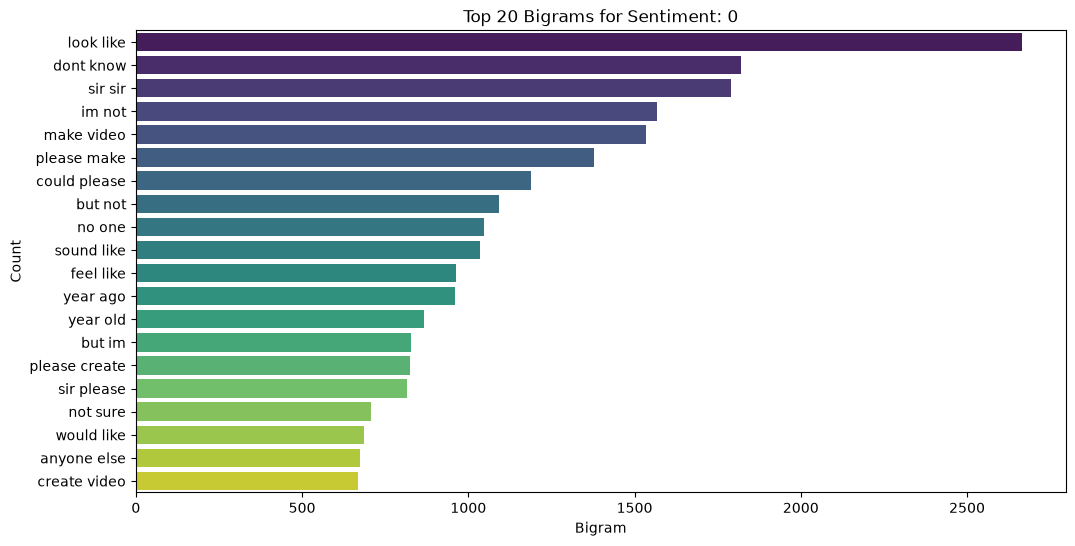

C:\Users\mitad\AppData\Local\Temp\ipykernel_18188\572103803.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_n_words_df, y='Bigram', x='Count',palette='viridis')


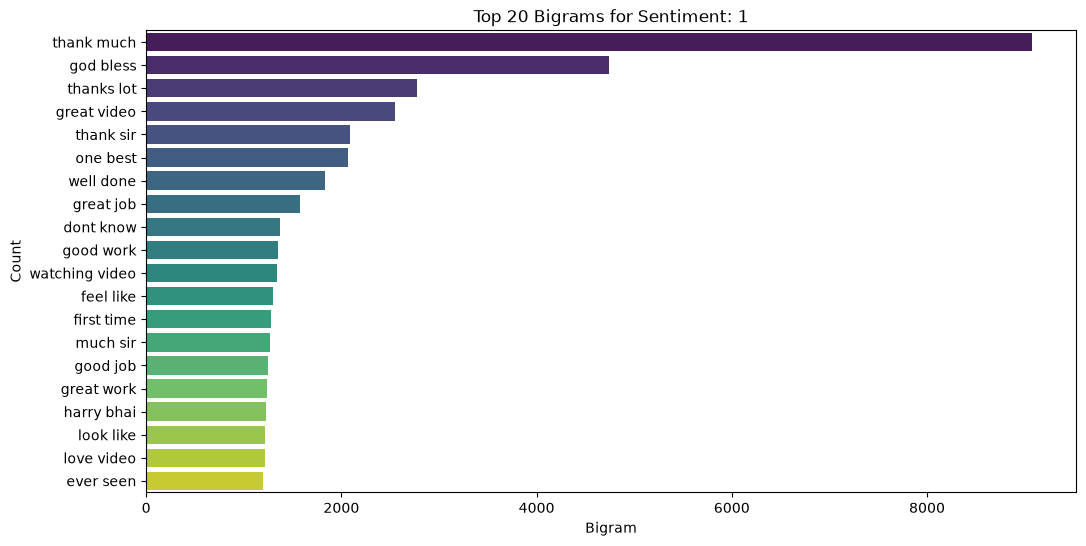

C:\Users\mitad\AppData\Local\Temp\ipykernel_18188\572103803.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_n_words_df, y='Bigram', x='Count',palette='viridis')


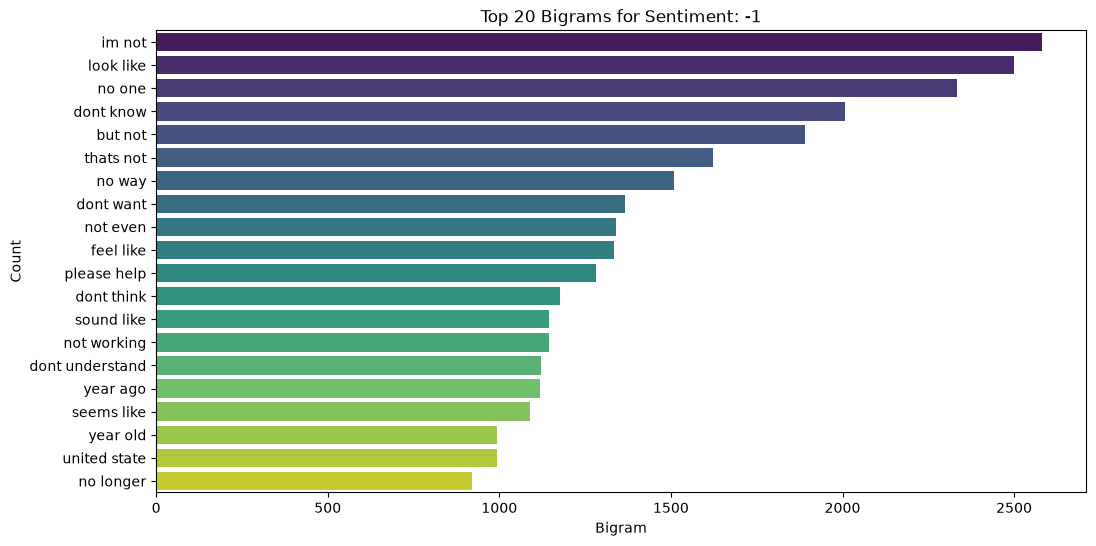

In [60]:
plot_top_n_words_by_sentiment(df, sentiment_col='Sentiment', text_col='CommentText', n=20)